In [ ]:
import MDAnalysis as mda
import MDAnalysis.analysis.msd as msd
from MDAnalysis.analysis.rdf import InterRDF
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import mdtraj as mdtraj

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [6]:
## Convert ase trajectory
# ! rm ../output/wat_mace_small/wat_300_nvt.pdb
! ase convert ../output/wat_mace_small/wat_300_nvt.traj ../output/wat_mace_small/wat_300_nvt.pdb

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
100%|██████████| 1716/1716 [00:00<00:00, 2491.32it/s]


Self Diffusion: 0.2467037454976545 A^2/ps
Self Diffusion: 2.467037454976545e-09 m^2/s


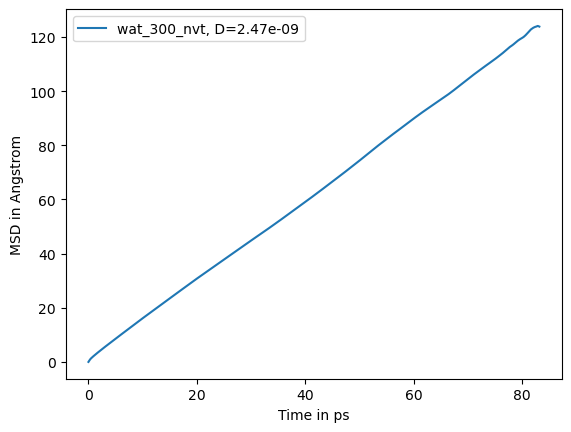

In [10]:
trajs = ["../output/wat_mace_small/wat_300_nvt.pdb"]
for traj in trajs:
    universe = mda.Universe(traj)
    atoms = universe.atoms
    transform = mda.transformations.NoJump(atoms)
    universe.trajectory.add_transformations(transform)
    MSD_mm = msd.EinsteinMSD(universe, select="all", msd_type="xyz", fft=True)
    MSD_mm.run(step=1)

    result_mm = MSD_mm.results.timeseries
    msd_all = result_mm
    nframes = MSD_mm.n_frames
    timestep = 0.05  # in ps,  this needs to be the actual time between frames
    lagtimes = np.arange(nframes) * timestep  # make the lag-time axis
    lag = lagtimes
    # plot the actual MSD
    # plt.show()

    # linear_model = linregress(lagtimes[500:-100], result_mm[500:-100])
    linear_model = linregress(lagtimes, result_mm)
    slope = linear_model.slope
    error = linear_model.stderr
    D = slope / 6
    print(f"Self Diffusion: {D} A^2/ps")
    print(f"Self Diffusion: {D*10**-8} m^2/s")
    diffusion = D * 10**-8
    plt.plot(
        lagtimes,
        result_mm,
        label=f'{traj.split("/")[-1].split(".")[0]}, D={diffusion:.2e}',
    )
    plt.ylabel("MSD in Angstrom")
    plt.xlabel("Time in ps")

    # ANI diffusion
plt.legend()
plt.show()